# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [3]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0)
]

In [4]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

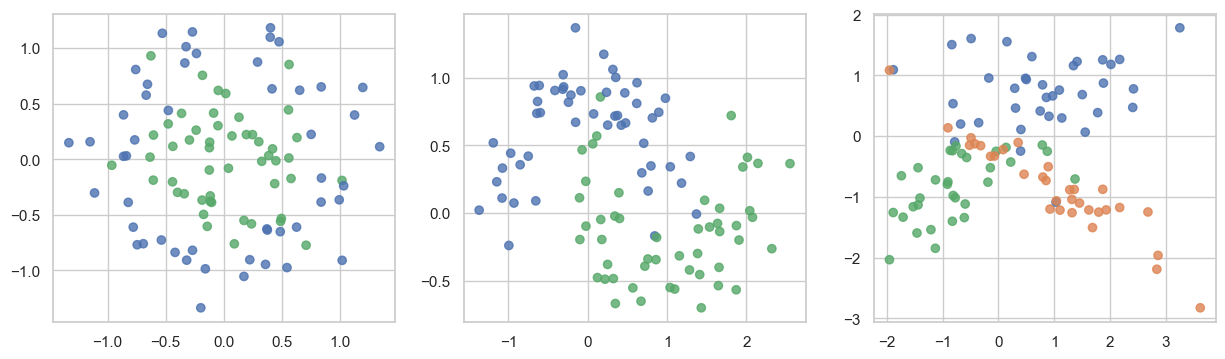

In [5]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [6]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

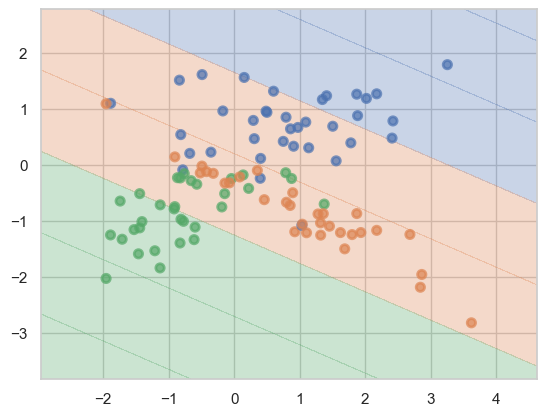

In [7]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Датасет 1:
  Точность на обучающей выборке: 1.0000
  Точность на тестовой выборке: 0.7333
  Переобучение: 0.2667

Датасет 2:
  Точность на обучающей выборке: 1.0000
  Точность на тестовой выборке: 0.8667
  Переобучение: 0.1333

Датасет 3:
  Точность на обучающей выборке: 1.0000
  Точность на тестовой выборке: 0.8333
  Переобучение: 0.1667



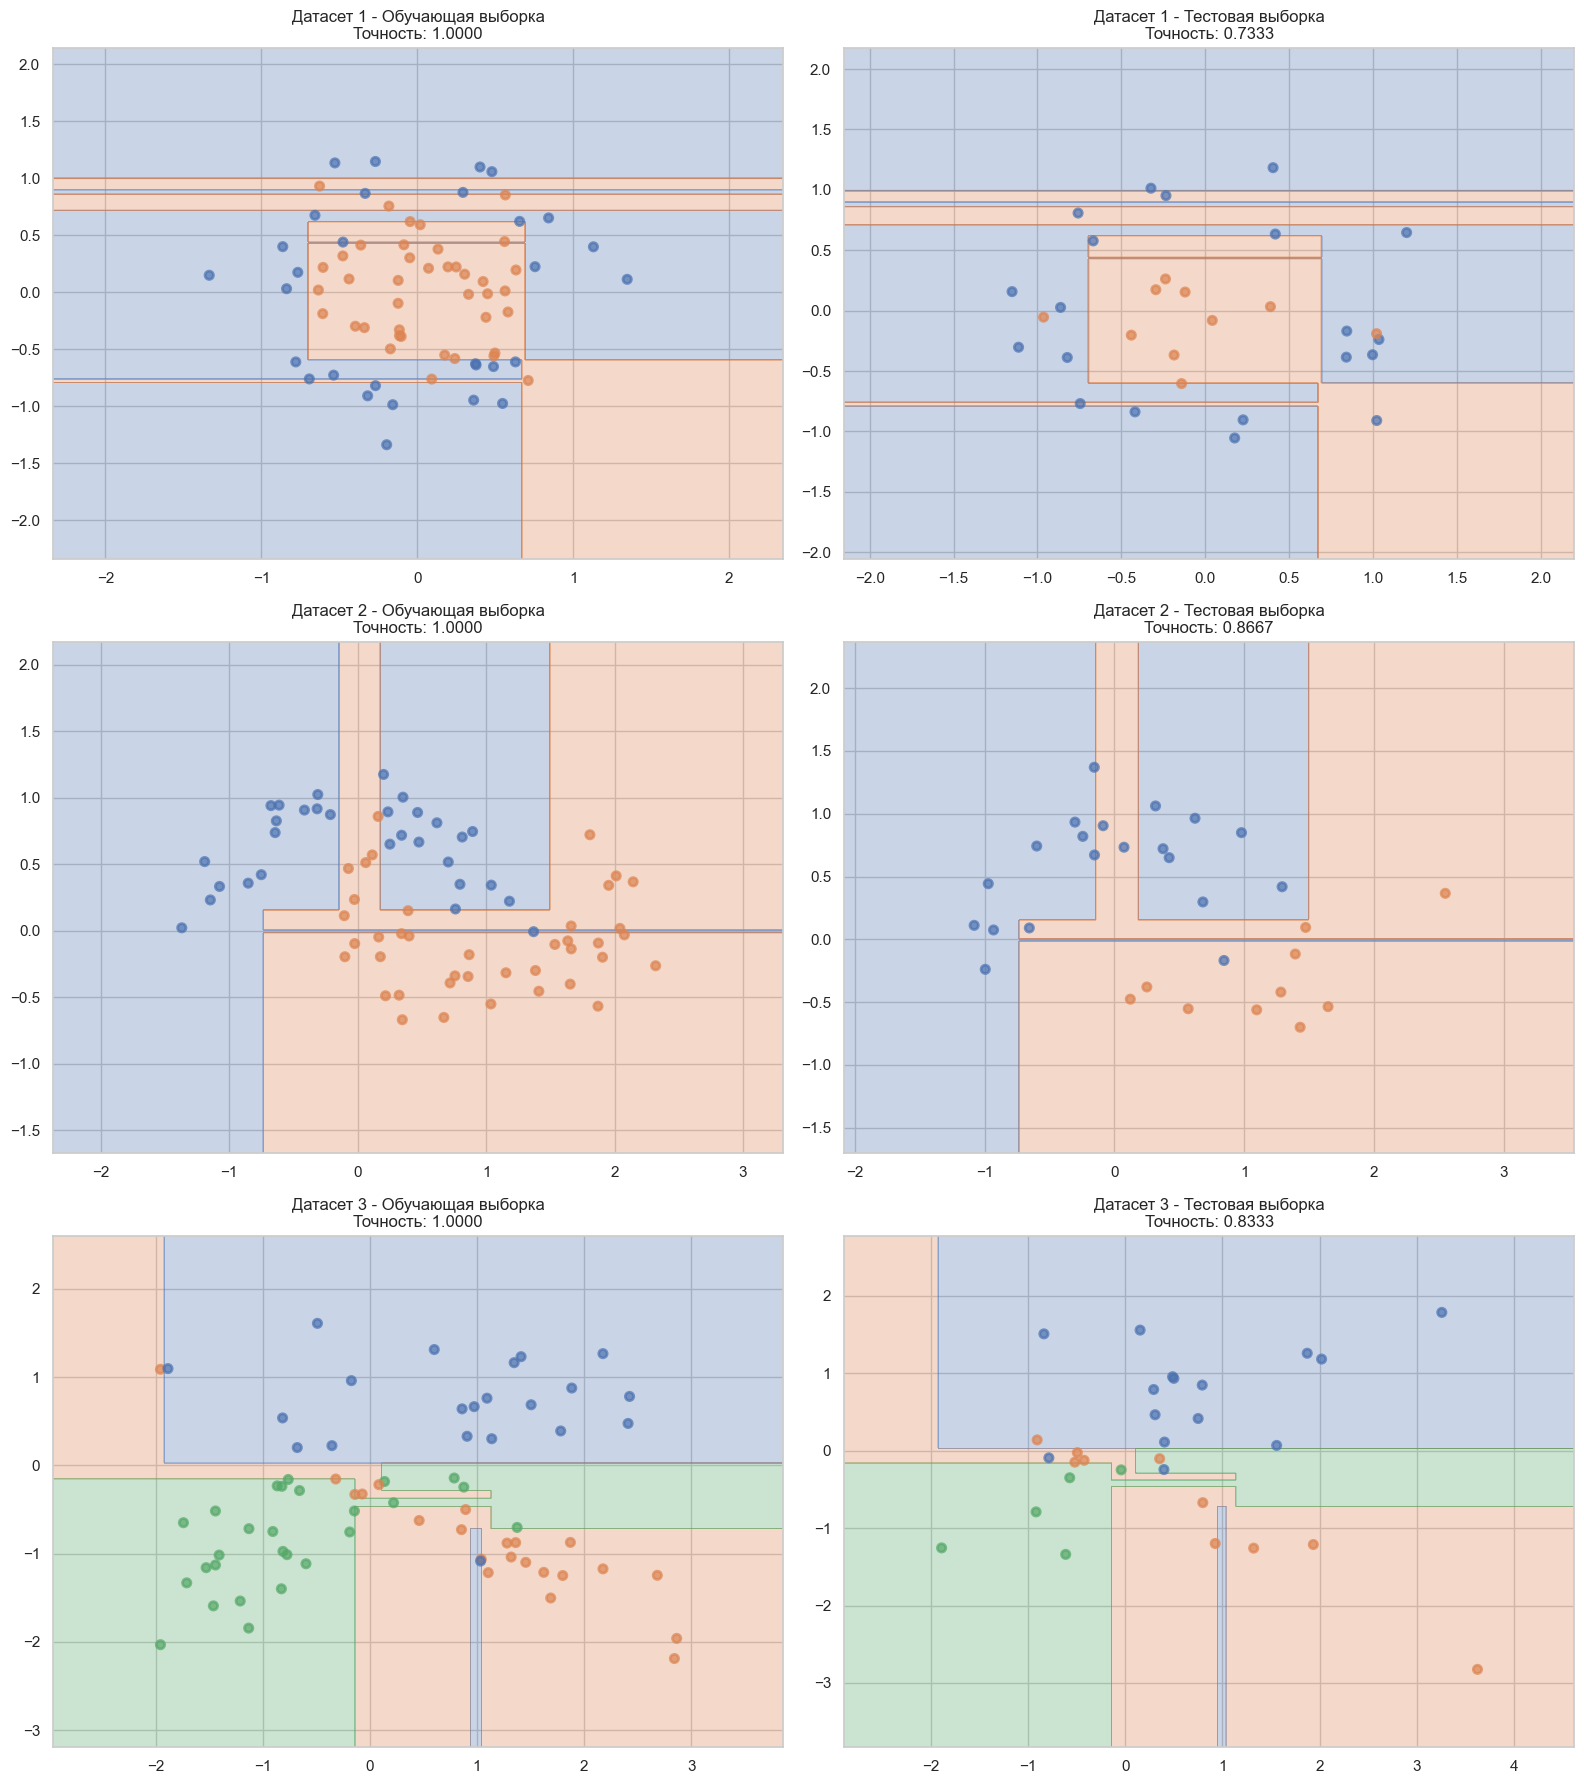

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.metrics import accuracy_score
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)
    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    print(f"Датасет {i+1}:")
    print(f"  Точность на обучающей выборке: {train_acc:.4f}")
    print(f"  Точность на тестовой выборке: {test_acc:.4f}")
    print(f"  Переобучение: {train_acc - test_acc:.4f}")
    print()
    ax1 = axes[i, 0]
    plt.sca(ax1)
    plot_surface(tree, X_train, y_train)
    ax1.set_title(f'Датасет {i+1} - Обучающая выборка\nТочность: {train_acc:.4f}')
    ax2 = axes[i, 1]
    plt.sca(ax2)
    plot_surface(tree, X_test, y_test)
    ax2.set_title(f'Датасет {i+1} - Тестовая выборка\nТочность: {test_acc:.4f}')
plt.tight_layout()
plt.show()

__Ответ:__  
Датасет 1 (make_circles): Дерево полностью запомнило обучающую выборку (accuracy = 1.0000), но качество на тесте значительно ниже. Это свидетельствует о сильном переобучении.  
Датасет 2 (make_moons): Аналогично, дерево переобучилось на обучающей выборке, но качество на тесте ниже. Переобучение выражено.  
Датасет 3 (make_classification): Также наблюдается переобучение, хотя разница между обучающей и тестовой точностью может быть меньше, чем в предыдущих случаях, в зависимости от конкретной выборки.  

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?


--- Анализ гиперпараметров для датасета 1 ---


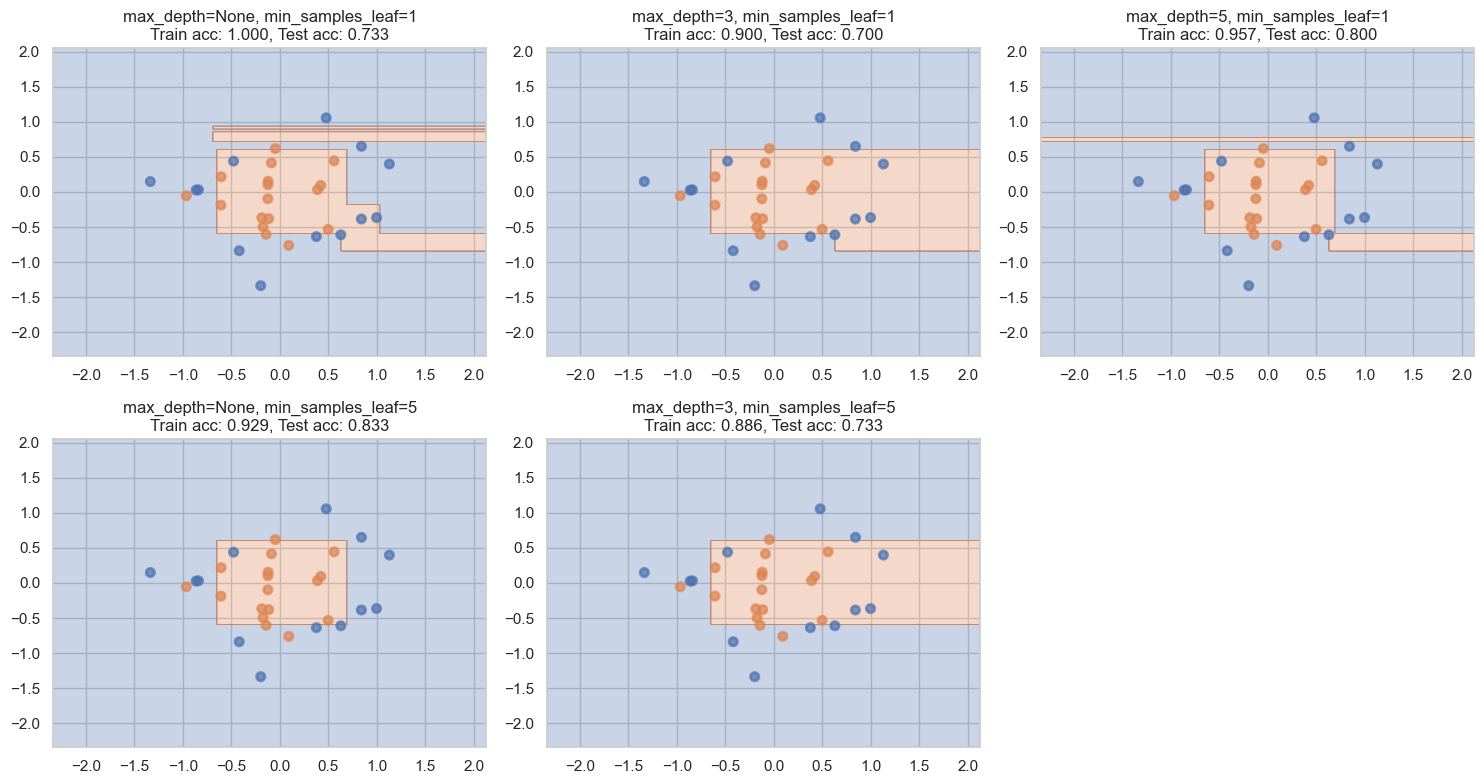

Параметры и точности для датасета 1:
  max_depth=None, min_samples_leaf=1: Train=1.000, Test=0.733, Diff=0.267
  max_depth=3, min_samples_leaf=1: Train=0.900, Test=0.700, Diff=0.200
  max_depth=5, min_samples_leaf=1: Train=0.957, Test=0.800, Diff=0.157
  max_depth=None, min_samples_leaf=5: Train=0.929, Test=0.833, Diff=0.095
  max_depth=3, min_samples_leaf=5: Train=0.886, Test=0.733, Diff=0.152

--- Анализ гиперпараметров для датасета 2 ---


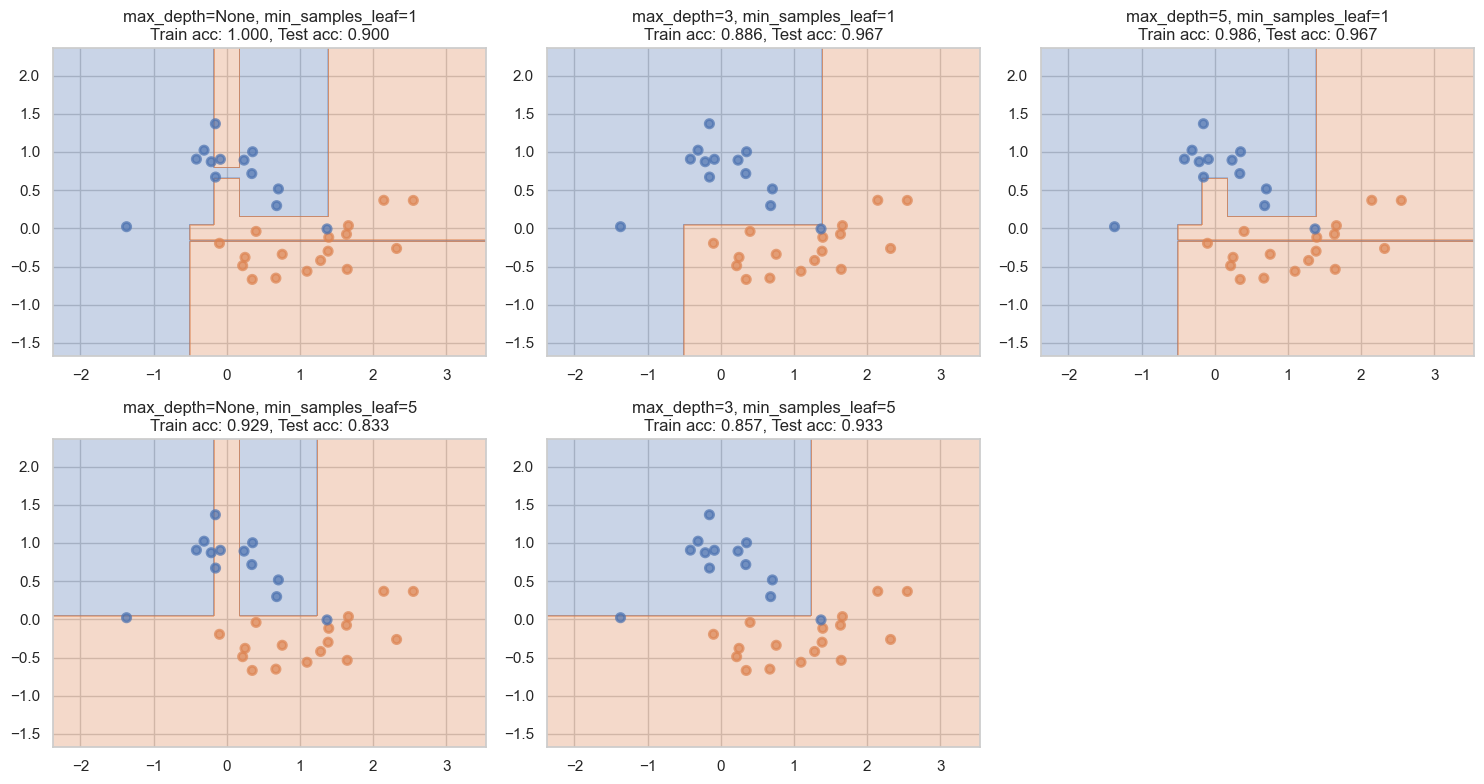

Параметры и точности для датасета 2:
  max_depth=None, min_samples_leaf=1: Train=1.000, Test=0.900, Diff=0.100
  max_depth=3, min_samples_leaf=1: Train=0.886, Test=0.967, Diff=-0.081
  max_depth=5, min_samples_leaf=1: Train=0.986, Test=0.967, Diff=0.019
  max_depth=None, min_samples_leaf=5: Train=0.929, Test=0.833, Diff=0.095
  max_depth=3, min_samples_leaf=5: Train=0.857, Test=0.933, Diff=-0.076

--- Анализ гиперпараметров для датасета 3 ---


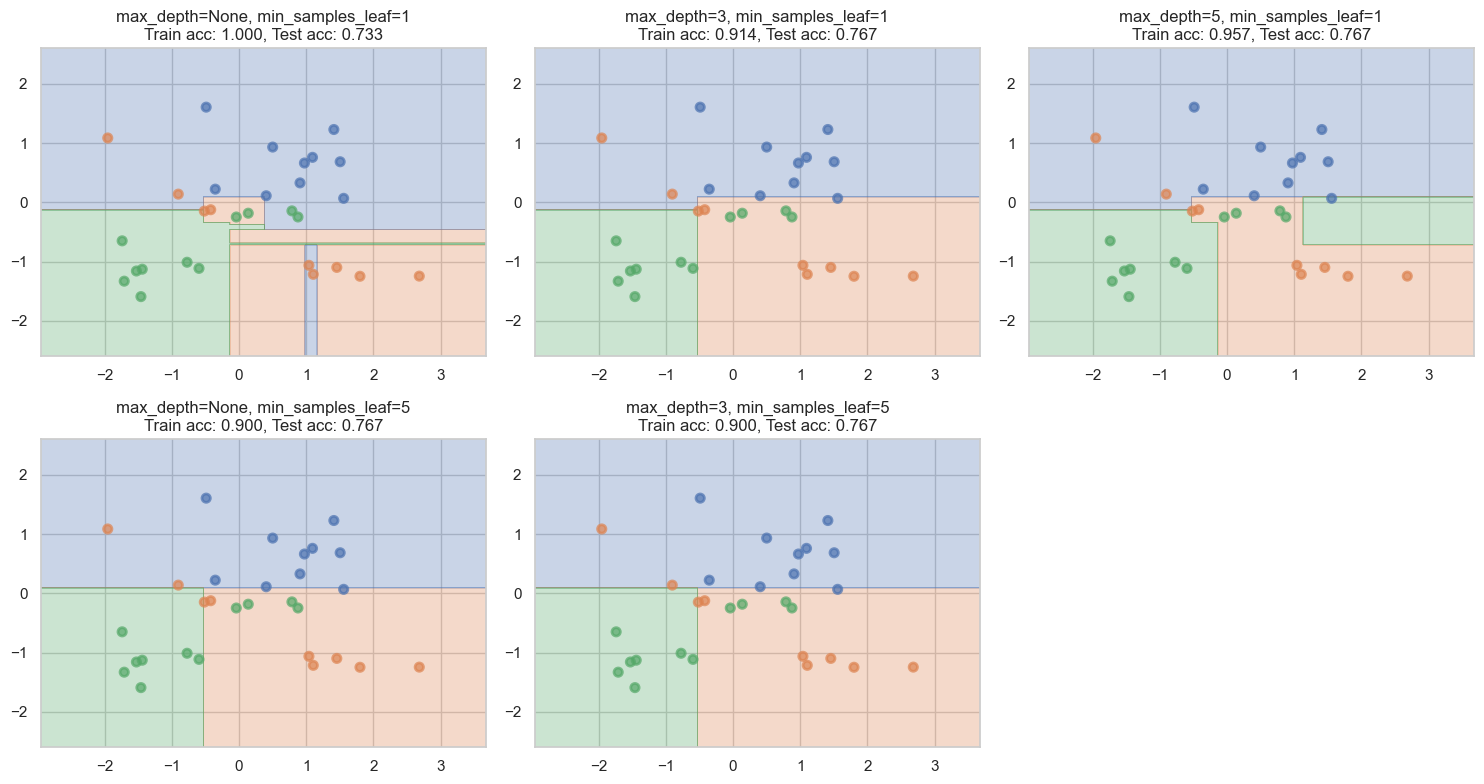

Параметры и точности для датасета 3:
  max_depth=None, min_samples_leaf=1: Train=1.000, Test=0.733, Diff=0.267
  max_depth=3, min_samples_leaf=1: Train=0.914, Test=0.767, Diff=0.148
  max_depth=5, min_samples_leaf=1: Train=0.957, Test=0.767, Diff=0.190
  max_depth=None, min_samples_leaf=5: Train=0.900, Test=0.767, Diff=0.133
  max_depth=3, min_samples_leaf=5: Train=0.900, Test=0.767, Diff=0.133


In [14]:


hyperparams_grid = [
    {'max_depth': None, 'min_samples_leaf': 1},
    {'max_depth': 3, 'min_samples_leaf': 1},
    {'max_depth': 5, 'min_samples_leaf': 1},
    {'max_depth': None, 'min_samples_leaf': 5},
    {'max_depth': 3, 'min_samples_leaf': 5},
]
for dataset_idx, (X, y) in enumerate(datasets):
    print(f"\n--- Анализ гиперпараметров для датасета {dataset_idx+1} ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    n_params = len(hyperparams_grid)
    n_cols = 3
    n_rows = int(np.ceil(n_params / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1:
        axes = axes if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()
    for i, params in enumerate(hyperparams_grid):
        tree = DecisionTreeClassifier(
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42
        )
        tree.fit(X_train, y_train)
        y_train_pred = tree.predict(X_train)
        y_test_pred = tree.predict(X_test)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        ax = axes[i]
        plt.sca(ax)
        plot_surface(tree, X_test, y_test)
        ax.set_title(f"max_depth={params['max_depth']}, min_samples_leaf={params['min_samples_leaf']}\n"
                     f"Train acc: {train_acc:.3f}, Test acc: {test_acc:.3f}")
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
    print("Параметры и точности для датасета {}:".format(dataset_idx+1))
    for params in hyperparams_grid:
        tree = DecisionTreeClassifier(
            max_depth=params['max_depth'],
            min_samples_leaf=params['min_samples_leaf'],
            random_state=42
        )
        tree.fit(X_train, y_train)
        y_train_pred = tree.predict(X_train)
        y_test_pred = tree.predict(X_test)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
        print(f"  max_depth={params['max_depth']}, min_samples_leaf={params['min_samples_leaf']}: "
              f"Train={train_acc:.3f}, Test={test_acc:.3f}, Diff={train_acc-test_acc:.3f}")


__Ответ:__  
Разделяющая поверхность становится проще при уменьшении max_depth и увеличении min_samples_leaf, что уменьшает переобучение. Это происходит из-за ограничения сложности модели. Изменения схожи для разных датасетов, но оптимальные параметры могут различаться.

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

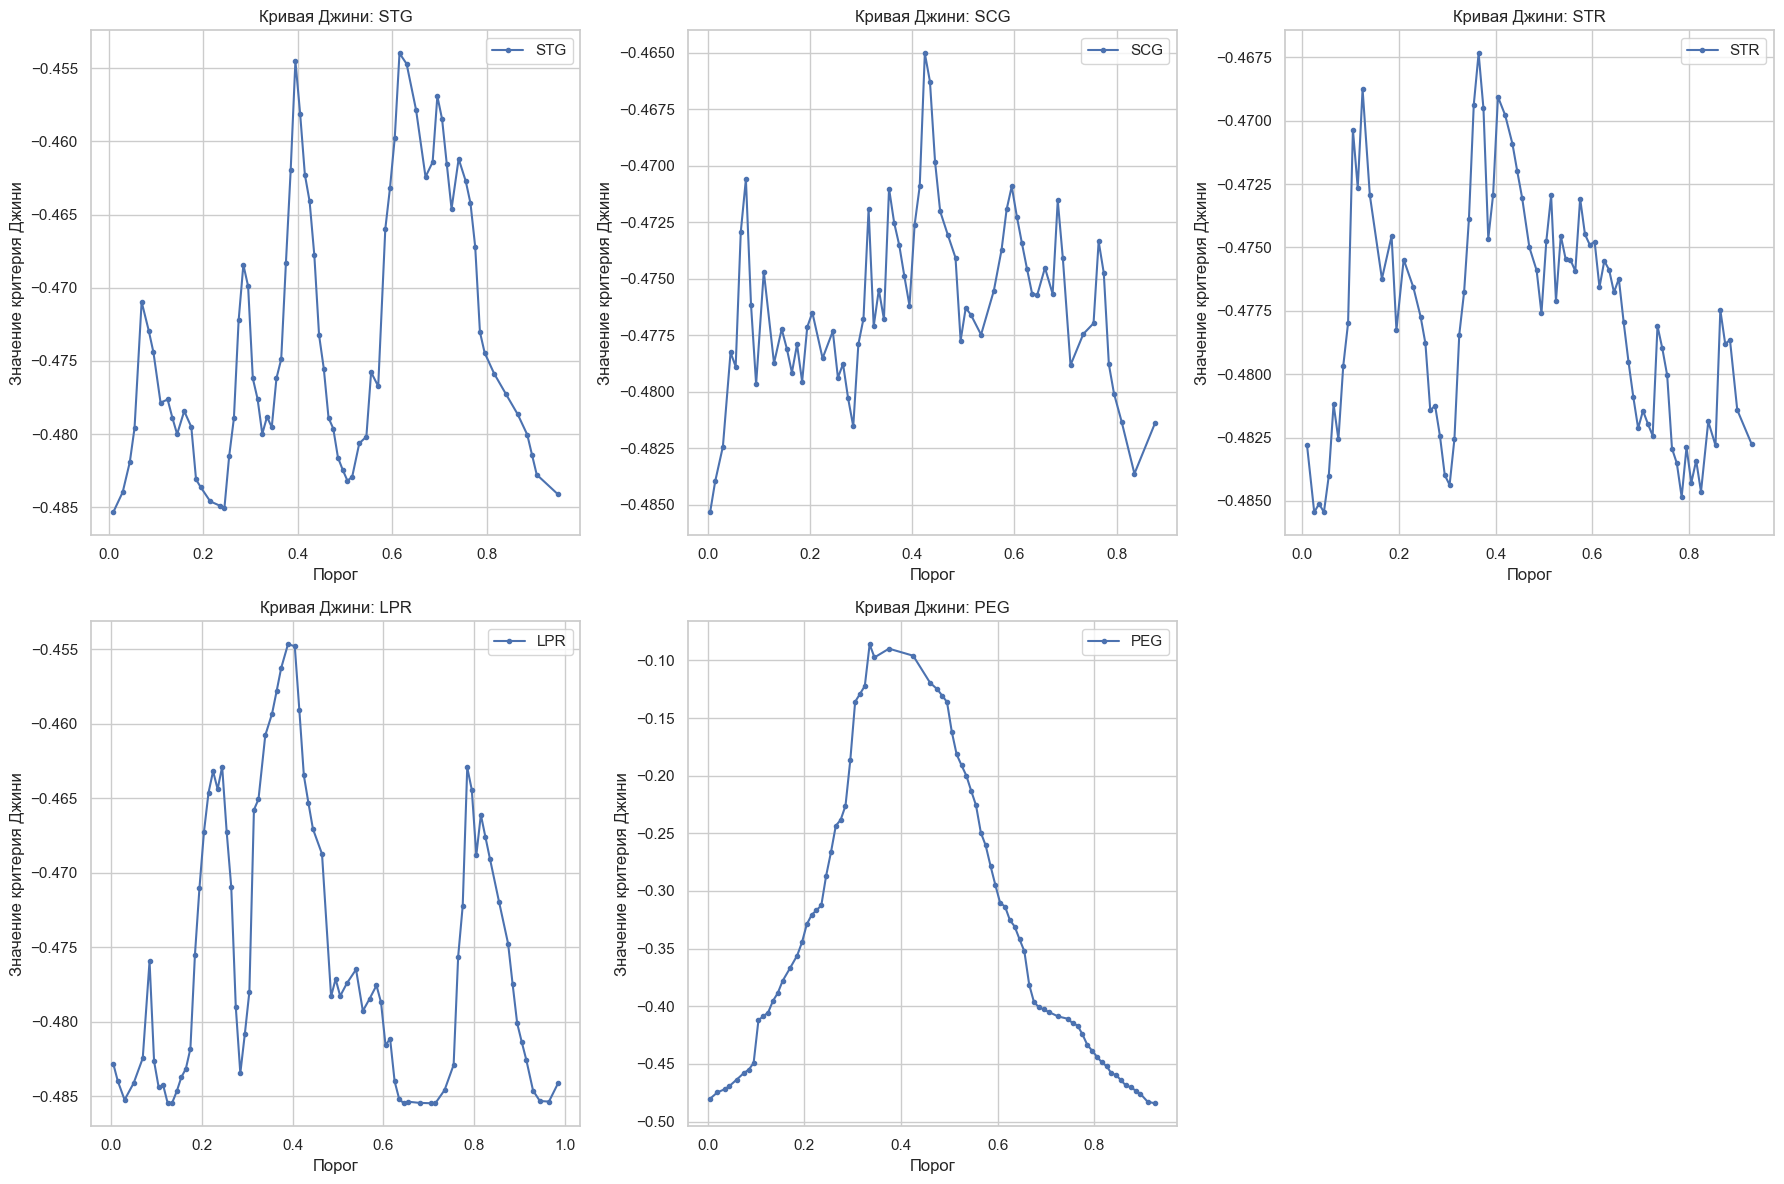

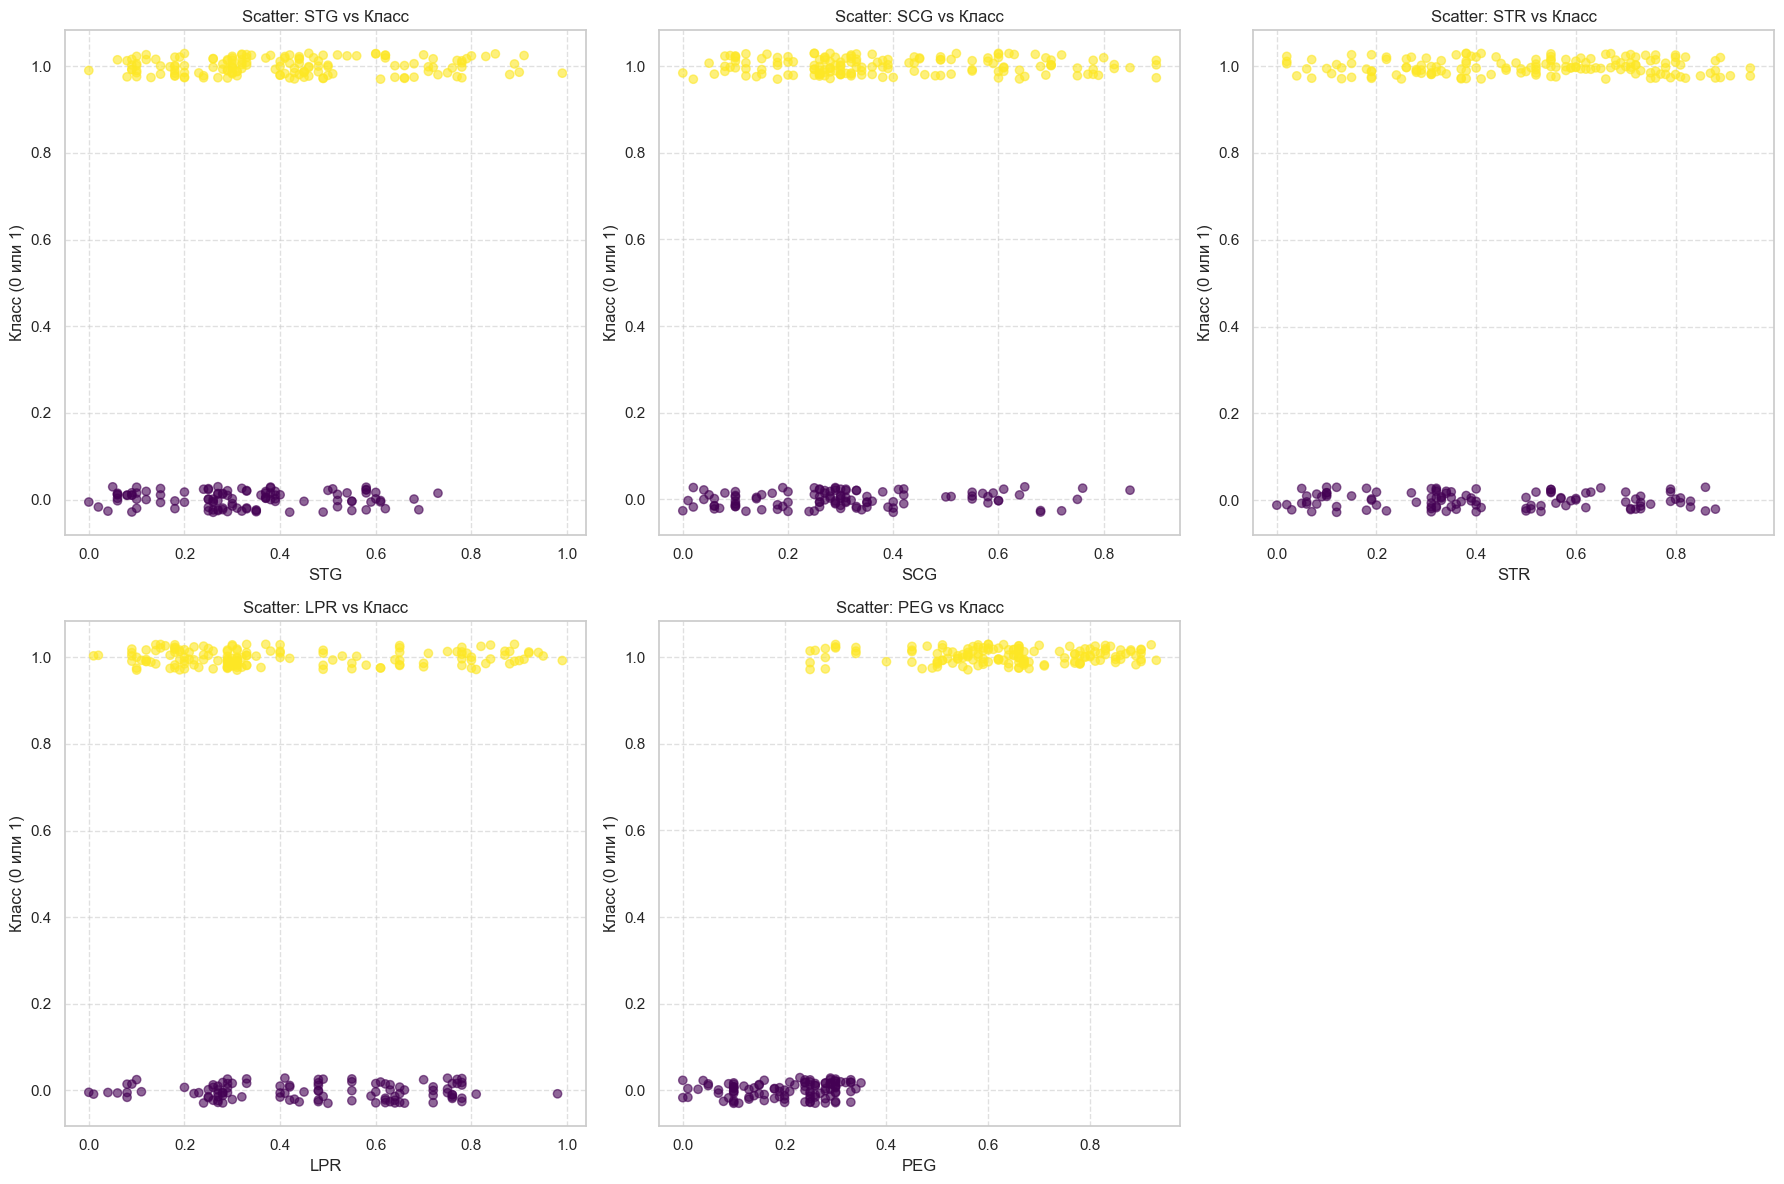

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
df = pd.read_csv('./datasets/students.csv')
from hw2code import find_best_split

features = df.columns[:-1].tolist()
target = df.columns[-1]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature_name in enumerate(features):
    feature_vector = df[feature_name].values
    target_vector = df[target].values
    thresholds, ginis, _, _ = find_best_split(feature_vector, target_vector)
    ax = axes[i]
    if len(thresholds) > 0:
        ax.plot(thresholds, ginis, label=f'{feature_name}', marker='o', markersize=3)
        ax.set_xlabel('Порог')
        ax.set_ylabel('Значение критерия Джини')
        ax.set_title(f'Кривая Джини: {feature_name}')
        ax.grid(True)
        ax.legend()
    else:
        ax.text(0.5, 0.5, f'Нет\nвозможных\nсплитов\nдля {feature_name}', 
                horizontalalignment='center', verticalalignment='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'Кривая Джини: {feature_name}')
        ax.set_xlabel('Порог')
        ax.set_ylabel('Значение критерия Джини')
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature_name in enumerate(features):
    ax = axes[i]
    y_jitter = df[target].apply(lambda x: x + np.random.uniform(-0.03, 0.03))
    ax.scatter(df[feature_name], y_jitter, c=df[target], cmap='viridis', alpha=0.6)
    ax.set_xlabel(feature_name)
    ax.set_ylabel('Класс (0 или 1)')
    ax.set_title(f'Scatter: {feature_name} vs Класс')
    ax.grid(True, linestyle='--', alpha=0.6)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:**  
Деление нужно производить по признаку с наименьшим минимальным значением критерия Джини (самой низкой точкой на кривой). Этот результат согласуется с scatter-графиками: признаки, где классы хорошо разделяются по значениям (меньше перекрытия), имеют более низкие минимумы на кривой Джини. Хорошие" признаки: Кривая имеет четко выраженный низкий минимум, что указывает на порог, при котором достигается почти идеальное разделение классов. 
"Плохие" признаки: Кривая остается на высоком уровне и не имеет выраженного минимума, что свидетельствует о слабой корреляции признака с целевой переменной и невозможности эффективно разделить выборку.

__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from hw2code import DecisionTree

df = pd.read_csv("./datasets/agaricus-lepiota.data", header=None)
X_df = df.iloc[:, 1:] 
y_df = df.iloc[:, 0] 
encoders = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values
feature_types = ["categorical"] * X.shape[1]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)
dt = DecisionTree(feature_types=feature_types)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.6f}")

def calculate_tree_depth(node):
    if node.get("type") == "terminal":
        return 1
    depth_of_left_subtree = calculate_tree_depth(node["left_child"])
    depth_of_right_subtree = calculate_tree_depth(node["right_child"])
    return 1 + max(depth_of_left_subtree, depth_of_right_subtree)
tree_depth = calculate_tree_depth(dt._tree)
print(f"depth: {tree_depth}")


Accuracy: 1.000000
depth: 8


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [12]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
    

__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

Вставьте что угодно, описывающее ваши впечатления от этого задания: